# Applied Exercise 6 - Gradient Descent

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ISLP import load_data
import os
import requests
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import RMSprop

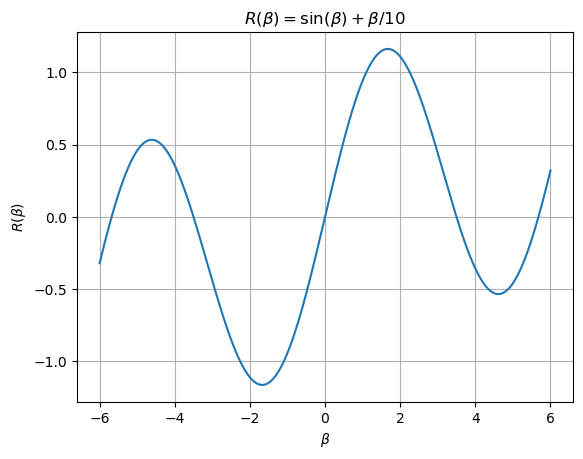

Derivate: cos(beta) + 1/10


In [3]:
beta = np.linspace(-6, 6, 500)
R = np.sin(beta) + beta/10

plt.plot(beta, R)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$R(\beta)$")
plt.title(r"$R(\beta)=\sin(\beta)+\beta/10$")
plt.grid()
plt.show()

print(r"Derivate: cos(beta) + 1/10")

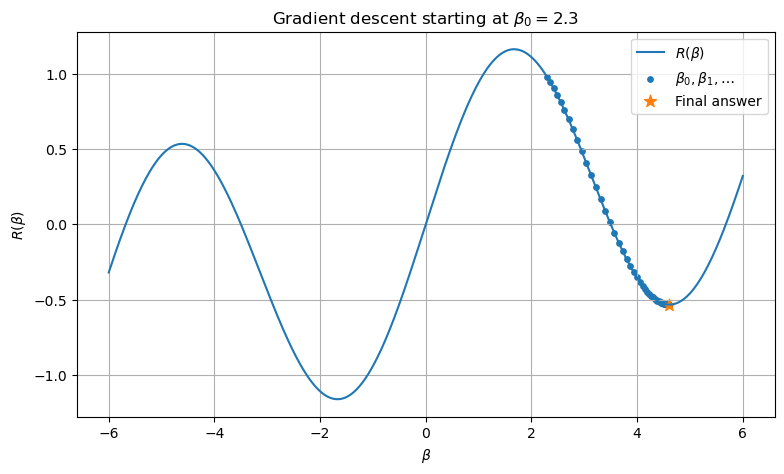

Number of iterations: 217
Final beta: 4.6122215583366595
Final R(beta): -0.533765281184307


In [4]:
beta = 2.3
rho = 0.1
betas = [beta]

for i in range(1000):
    beta_new = beta - rho*(np.cos(beta) + 0.1)
    betas.append(beta_new)
    if abs(beta_new - beta) < 1e-10: break
    beta = beta_new

betas = np.array(betas)
beta_grid = np.linspace(-6, 6, 500)
R_grid = np.sin(beta_grid) + beta_grid/10

plt.figure(figsize=(9,5))
plt.plot(beta_grid, R_grid, label=r"$R(\beta)$")
plt.scatter(betas, np.sin(betas) + betas/10, s=15, label=r"$\beta_0,\beta_1,\ldots$")
plt.scatter(betas[-1], np.sin(betas[-1]) + betas[-1]/10, s=80, marker="*", label="Final answer")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$R(\beta)$")
plt.title(r"Gradient descent starting at $\beta_0=2.3$")
plt.legend()
plt.grid()
plt.show()

print("Number of iterations:", len(betas)-1)
print("Final beta:", betas[-1])
print("Final R(beta):", np.sin(betas[-1]) + betas[-1]/10)

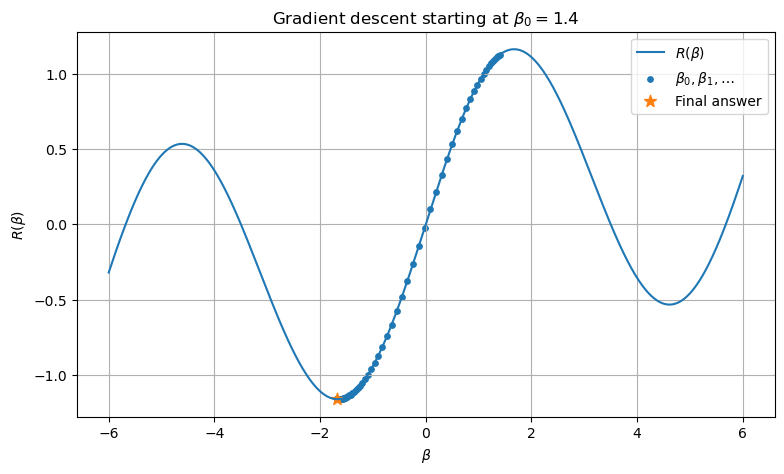

Number of iterations: 227
Final beta: -1.6709637471085945
Final R(beta): -1.1620838119022656


In [5]:
beta = 1.4
rho = 0.1
betas = [beta]

for i in range(1000):
    beta_new = beta - rho*(np.cos(beta) + 0.1)
    betas.append(beta_new)
    if abs(beta_new - beta) < 1e-10: break
    beta = beta_new

betas = np.array(betas)
beta_grid = np.linspace(-6, 6, 500)
R_grid = np.sin(beta_grid) + beta_grid/10

plt.figure(figsize=(9,5))
plt.plot(beta_grid, R_grid, label=r"$R(\beta)$")
plt.scatter(betas, np.sin(betas) + betas/10, s=15, label=r"$\beta_0,\beta_1,\ldots$")
plt.scatter(betas[-1], np.sin(betas[-1]) + betas[-1]/10, s=80, marker="*", label="Final answer")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$R(\beta)$")
plt.title(r"Gradient descent starting at $\beta_0=1.4$")
plt.legend()
plt.grid()
plt.show()

print("Number of iterations:", len(betas)-1)
print("Final beta:", betas[-1])
print("Final R(beta):", np.sin(betas[-1]) + betas[-1]/10)

The above demonstrates that Gradient descent does not always capture the global minima. The initial value of the parameters have to be chosen carefully to be not stuck in a local minima.

# Applied Exercise 7 - Neural network on Default data

In [6]:
Default = load_data("Default")
Default["default"] = (Default["default"] == "Yes").astype(int)
X = pd.get_dummies(Default.drop(columns="default"), drop_first=True, dtype=int)
y = Default["default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Logistic regression
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_s, y_train)
logit_pred = logit.predict(X_test_s)

# Neural network: 1 hidden layer, 10 units, dropout
nn = keras.Sequential([keras.layers.Input(shape=(X_train_s.shape[1],)), keras.layers.Dense(10, activation="relu"), keras.layers.Dropout(0.5), keras.layers.Dense(1, activation="sigmoid")])
nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
nn.fit(X_train_s, y_train, epochs=50, batch_size=32, verbose=0)

nn_pred = (nn.predict(X_test_s, verbose=0).ravel() >= 0.5).astype(int)

print("=" * 60)
print("CLASSIFICATION PERFORMANCE")
print("=" * 60)
print("Logistic regression test error:", 1 - accuracy_score(y_test, logit_pred))
print("Neural network test error:", 1 - accuracy_score(y_test, nn_pred))
print("\nLogistic regression confusion matrix:")
print(confusion_matrix(y_test, logit_pred))
print("\nNeural network confusion matrix:")
print(confusion_matrix(y_test, nn_pred))

CLASSIFICATION PERFORMANCE
Logistic regression test error: 0.026000000000000023
Neural network test error: 0.03200000000000003

Logistic regression confusion matrix:
[[1924    9]
 [  43   24]]

Neural network confusion matrix:
[[1932    1]
 [  63    4]]


Logistic regression provides better classification performance than the neural network for these data. Its test error is lower (2.6% vs. 3.2%), and it also identifies substantially more customers who default. The neural network's additional nonlinear flexibility does not improve performance here. This does not mean logistic regression is better than neural network but better for this specific data split.

# Applied Exercise 8 - CNN on images

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\sumuk\tensorflow_datasets\oxford_iiit_pet\incomplete.KFGZA1_4.0.0\oxford_iiit_pet-train.tfr…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\sumuk\tensorflow_datasets\oxford_iiit_pet\incomplete.KFGZA1_4.0.0\oxford_iiit_pet-test.tfre…

Dataset oxford_iiit_pet downloaded and prepared to C:\Users\sumuk\tensorflow_datasets\oxford_iiit_pet\4.0.0. Subsequent calls will reuse this data.
A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 2cb95161c43110f7111970584f804107 so we will re-download the data.
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 86s 1us/step 


35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


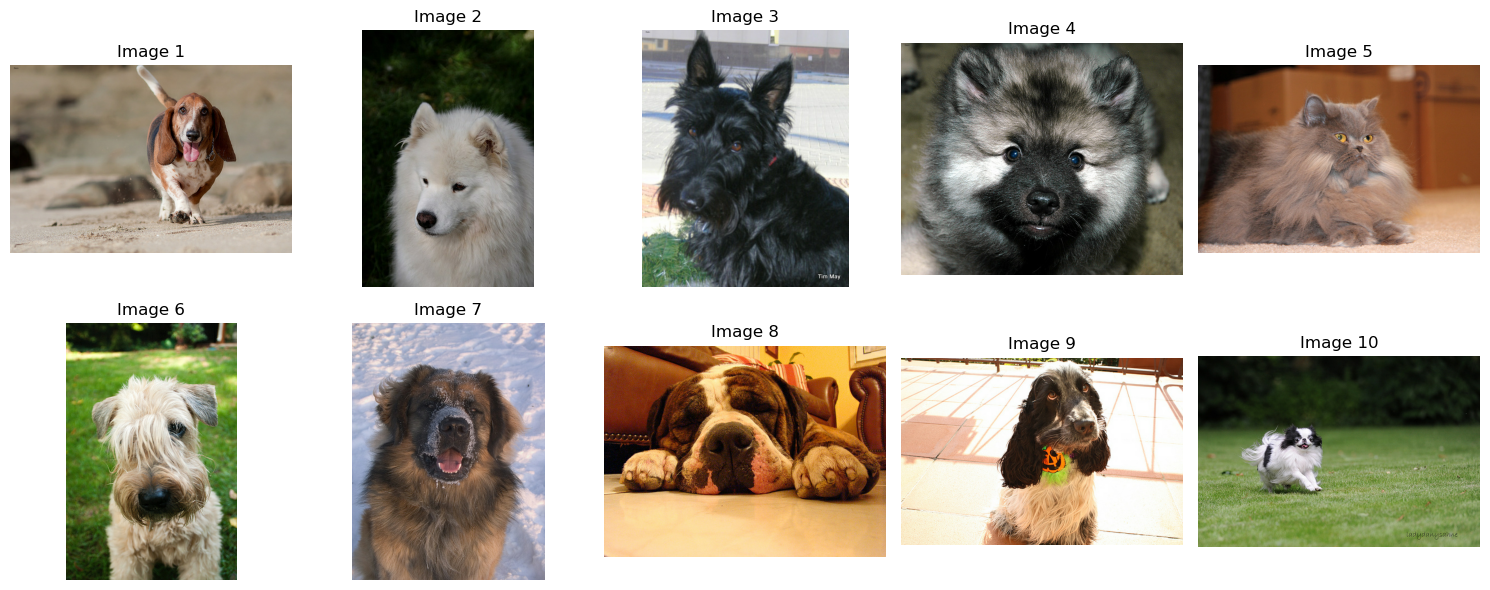

 Image  Rank             Predicted Class  Probability
     1     1                      basset     0.878890
     1     2                      Saluki     0.089663
     1     3                  bloodhound     0.009156
     1     4                Walker_hound     0.006992
     1     5      Welsh_springer_spaniel     0.003994
     2     1                     Samoyed     0.833125
     2     2                  white_wolf     0.117452
     2     3                  Arctic_fox     0.038257
     2     4                 timber_wolf     0.002799
     2     5                        chow     0.002267
     3     1              Scotch_terrier     0.989829
     3     2                       cairn     0.003674
     3     3             giant_schnauzer     0.002098
     3     4         miniature_schnauzer     0.001441
     3     5                      briard     0.001010
     4     1                    keeshond     0.998985
     4     2                        chow     0.000686
     4     3          Norweg

In [2]:
# Load Oxford-IIIT Pet dataset and select 10 random images
ds = tfds.load("oxford_iiit_pet", split="test", as_supervised=True)
samples = list(ds.shuffle(1000, seed=1).take(10))

# Pretrained ImageNet CNN
model = ResNet50(weights="imagenet")

results = []
for i, (image, true_label) in enumerate(samples, 1):
    image_np = image.numpy()
    image_resized = tf.image.resize(image, (224, 224)).numpy()
    x = preprocess_input(np.expand_dims(image_resized, axis=0))

    predictions = model.predict(x, verbose=0)
    top5 = decode_predictions(predictions, top=5)[0]

    for rank, (_, label, probability) in enumerate(top5, 1):
        results.append([i, rank, label, probability])

# Display the 10 selected images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ((image, label), ax) in enumerate(zip(samples, axes.ravel()), 1):
    ax.imshow(image)
    ax.set_title(f"Image {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Top-5 predictions
results = pd.DataFrame(results, columns=["Image", "Rank", "Predicted Class", "Probability"])
print(results.to_string(index=False))

# Applied Exercise 9 - Autoregression Trees

In [11]:
NYSE = load_data("NYSE")
NYSE["month"] = pd.to_datetime(NYSE.index).month.astype("category")

for i in range(1, 6):
    NYSE[f"Lag{i}"] = NYSE["DJ_return"].shift(i)

NYSE = NYSE.dropna().copy()

train = NYSE[NYSE["train"] == True]
test = NYSE[NYSE["train"] == False]

In [12]:
# Model 1 - AR(5)
lags = [f"Lag{i}" for i in range(1, 6)]

X_train = sm.add_constant(train[lags])
X_test = sm.add_constant(test[lags])
y_train = train["DJ_return"]
y_test = test["DJ_return"]

model1 = sm.OLS(y_train, X_train).fit()
pred1 = model1.predict(X_test)

# Model 2 - AR(5) + month factor
X_train_month = pd.get_dummies(train[lags + ["month"]], drop_first=True, dtype=int)
X_test_month = pd.get_dummies(test[lags + ["month"]], drop_first=True, dtype=int)
X_test_month = X_test_month.reindex(columns=X_train_month.columns, fill_value=0)

X_train_month = sm.add_constant(X_train_month)
X_test_month = sm.add_constant(X_test_month)

model2 = sm.OLS(y_train, X_train_month).fit()
pred2 = model2.predict(X_test_month)

In [16]:
# Comparision
mse1 = mean_squared_error(y_test, pred1)
mse2 = mean_squared_error(y_test, pred2)

print("=" * 60)
print("AR(5) vs AR(5) + MONTH")
print("=" * 60)

print(f"\nAR(5) Test MSE:           {mse1:.6f}")
print(f"AR(5) + Month Test MSE:   {mse2:.6f}")

print(f"\nAR(5) R²:                 {model1.rsquared:.6f}")
print(f"AR(5) + Month R²:         {model2.rsquared:.6f}")

print(f"\nChange in Test MSE:       {mse2 - mse1:.6f}")
print(f"\nChange in R²:       {model2.rsquared - model1.rsquared:.6f}")

AR(5) vs AR(5) + MONTH

AR(5) Test MSE:           0.000088
AR(5) + Month Test MSE:   0.000088

AR(5) R²:                 0.040806
AR(5) + Month R²:         0.044308

Change in Test MSE:       0.000000

Change in R²:       0.003502


The test error remains the same with the addition of month actor but it was able to explain 0.35% more than the base model which is negligible.

# Applied Exercise 10 - Regression using AR vs RNN

In [23]:
returns = NYSE["DJ_return"].values
train_flag = NYSE["train"].values
X, y, is_train = [], [], []

for i in range(5, len(returns)):
    X.append(returns[i-5:i])
    y.append(returns[i])
    is_train.append(train_flag[i])

X = np.array(X)
y = np.array(y)
is_train = np.array(is_train)

# Flattened RNN Sequences -> Linear AR model
X_train = X[is_train]
X_test = X[~is_train]
y_train = y[is_train]
y_test = y[~is_train]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_r2_flattened = r2_score(y_test, y_pred)

In [24]:
# Same AR(5) model, constructed directly from Lag1-Lag5
NYSE_lab = NYSE.copy()

for i in range(1, 6):
    NYSE_lab[f"Lag{i}"] = NYSE_lab["DJ_return"].shift(i)

NYSE_lab = NYSE_lab.dropna()
train_lab = NYSE_lab[NYSE_lab["train"] == True]
test_lab = NYSE_lab[NYSE_lab["train"] == False]
lags = [f"Lag{i}" for i in range(1, 6)]

X_train_lab = train_lab[lags]
X_test_lab = test_lab[lags]
y_train_lab = train_lab["DJ_return"]
y_test_lab = test_lab["DJ_return"]

model_lab = LinearRegression()
model_lab.fit(X_train_lab, y_train_lab)

y_pred_lab = model_lab.predict(X_test_lab)
test_r2_lab = r2_score(y_test_lab, y_pred_lab)

In [20]:
# Comparision
print("=" * 60)
print("LINEAR AR MODEL")
print("=" * 60)

print(f"\nFlattened-sequence AR(5) test R²: {test_r2_flattened:.6f}")
print(f"Lab AR(5) test R²:                {test_r2_lab:.6f}")
print(f"\nDifference:                       {test_r2_flattened - test_r2_lab:.6f}")

LINEAR AR MODEL

Flattened-sequence AR(5) test R²: -0.028469
Lab AR(5) test R²:                -0.028469

Difference:                       -0.000000


When flattened data is used, it just gives the 5 predictors used which is essentially what Linear Regression needs and hence both R-squared values are identical and they are fitting the AR(5) model only.
- Direct AR using Lag1–Lag5 is simple and easy to interpret but each lag has to be explicitly constructed.
- Flattened RNN sequences use same data structure can be fed directly into an RNN or flattened for linear regression and is convenient for comparing models but less intuitive for ordinary linear regression; flattening loses the sequential structure that makes an RNN useful

# Applied Exercise 11 - Regression using Non-Linear AR vs RNN

In [27]:
returns = NYSE["DJ_return"].values
train_flag = NYSE["train"].values

X, y, is_train = [], [], []

for i in range(5, len(returns)):
    X.append(returns[i-5:i])
    y.append(returns[i])
    is_train.append(train_flag[i])

X = np.array(X)
y = np.array(y)
is_train = np.array(is_train)

X_train = X[is_train]
X_test = X[~is_train]
y_train = y[is_train]
y_test = y[~is_train]

In [28]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = X_scaler.fit_transform(X_train)
X_test_s = X_scaler.transform(X_test)
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

# Non-Linear AR model
model = MLPRegressor(hidden_layer_sizes=(10,), activation="relu", solver="adam", max_iter=1000, random_state=1)
model.fit(X_train_s, y_train_s)

# Predictions
y_pred_s = model.predict(X_test_s)
y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

test_r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("NONLINEAR AR MODEL")
print("=" * 60)
print(f"Test R²: {test_r2:.6f}")

NONLINEAR AR MODEL
Test R²: -0.030164


- The nonlinear AR model was fit by flattening the five-period sequences used for the RNN model and then fitting a neural network with one hidden layer containing 10 neurons. The model achieved a test R^2 of -0.030164.
- The negative test R^2 indicates that the nonlinear AR model performs slightly worse than simply predicting the mean NYSE return. Thus, allowing nonlinear relationships among the five lagged returns does not provide a meaningful improvement in out-of-sample prediction for this dataset.

# Applied Exercise 12 - RNN on NYSE data

In [4]:
data = load_data("NYSE")
day_order = ["mon", "tue", "wed", "thu", "fri"]
data["day_of_week"] = pd.Categorical(data["day_of_week"], categories=day_order, ordered=True).codes

features = ["day_of_week", "DJ_return", "log_volume", "log_volatility"]
X_raw = data[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

train_flag = data["train"].values

X, y, is_train = [], [], []
for i in range(5, len(data)):
    X.append(X_scaled[i-5:i])
    y.append(X_scaled[i, 2])
    is_train.append(train_flag[i])

X = np.array(X)
y = np.array(y)
is_train = np.array(is_train)

X_train = X[is_train]
X_test = X[~is_train]
y_train = y[is_train]
y_test = y[~is_train]

print("=" * 60)
print("RNN with day of week on NYSE data")
print("=" * 60)
print(f"\nTraining shape: {X_train.shape}")
print(f"Test shape:     {X_test.shape}")

RNN with day of week on NYSE data

Training shape: (4276, 5, 4)
Test shape:     (1770, 5, 4)


In [5]:
model = Sequential([SimpleRNN(12, input_shape=(5, 4), dropout=0.1, recurrent_dropout=0.1), Dense(1)])
model.compile(optimizer=RMSprop(), loss="mse")
history = model.fit(X_train, y_train, batch_size=64, epochs=200, validation_data=(X_test, y_test), verbose=0)

# Test R^2
y_pred = model.predict(X_test, verbose=0).ravel()
test_r2 = r2_score(y_test, y_pred)
print(f"\nTest R²: {test_r2:.6f}")


Test R²: 0.450236
